In [1]:
#1.Entrenar modelo.
#2.Calcular Precision, Recall, F1.
#3.Graficar curva ROC.
#4.Reportar AUC.
#5.Explicar cuál métrica sería más importante si fuera un banco.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_curve, auc, roc_auc_score,
                            confusion_matrix, classification_report)


In [3]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

y_binary = (y > y.mean()).astype(int)

print("forma de X:", X.shape)
print("distribucion de clases:")
print(pd.Series(y_binary).value_counts())
print("\n" + "="*50 + "\n")

forma de X: (442, 10)
distribucion de clases:
0    247
1    195
Name: count, dtype: int64




In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42, stratify=+y_binary)

print(f"tamaño de entrenamiento: {X_train.shape}")
print(f"tamaño de prueba: {X_test.shape}")
print("\n" + "="*50 + "\n")

tamaño de entrenamiento: (309, 10)
tamaño de prueba: (133, 10)




In [5]:
modelo = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
modelo.fit(X_train, y_train)

print("Modelo entrenado exitosamente.")
print("\n" + "="*50 + "\n")

Modelo entrenado exitosamente.




In [6]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]  # Probabilidades para clase positiva (1)

In [7]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("📊 **MÉTRICAS DE EVALUACIÓN**")
print("-" * 30)
print(f"Precisión: {precision:.4f}")
print(f"Recall (Sensibilidad): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")
print("\n" + "="*50 + "\n")


📊 **MÉTRICAS DE EVALUACIÓN**
------------------------------
Precisión: 0.7500
Recall (Sensibilidad): 0.7119
F1-Score: 0.7304
Exactitud (Accuracy): 0.7669
AUC-ROC: 0.8514




In [8]:
print("📋 **REPORTE DE CLASIFICACIÓN**")
print("-" * 30)
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))
print("="*50 + "\n")

📋 **REPORTE DE CLASIFICACIÓN**
------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.78      0.81      0.79        74
    Diabetes       0.75      0.71      0.73        59

    accuracy                           0.77       133
   macro avg       0.76      0.76      0.76       133
weighted avg       0.77      0.77      0.77       133




In [9]:
cm = confusion_matrix(y_test, y_pred)
print("🔢 **MATRIZ DE CONFUSIÓN**")
print("-" * 30)
print("                 Predicho")
print("                No    Sí")
print(f"Real: No     {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"      Sí     {cm[1,0]:4d}  {cm[1,1]:4d}")
print("\n" + "="*50 + "\n")

🔢 **MATRIZ DE CONFUSIÓN**
------------------------------
                 Predicho
                No    Sí
Real: No       60    14
      Sí       17    42




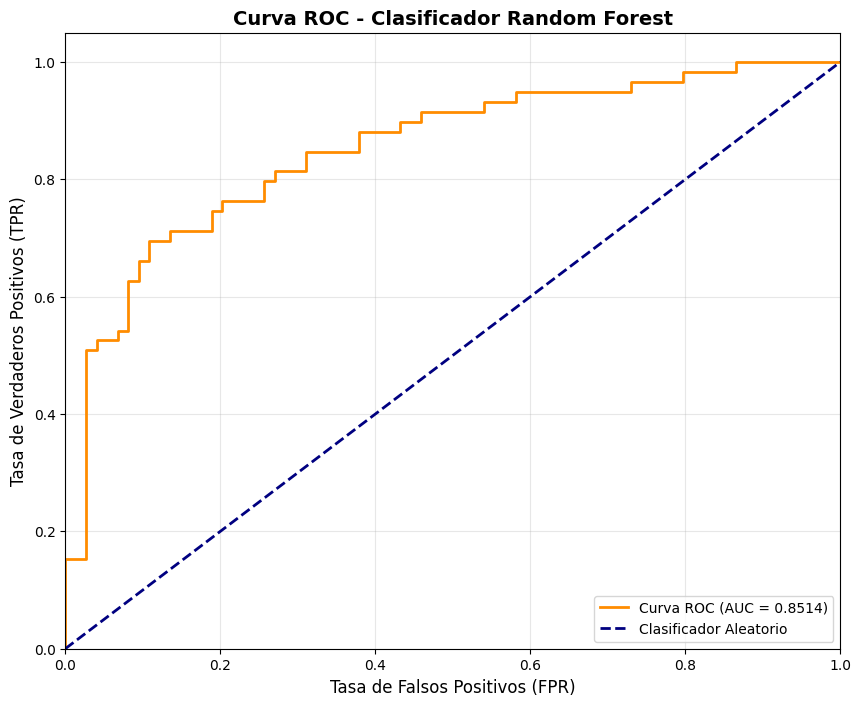

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
            label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
            label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Clasificador Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

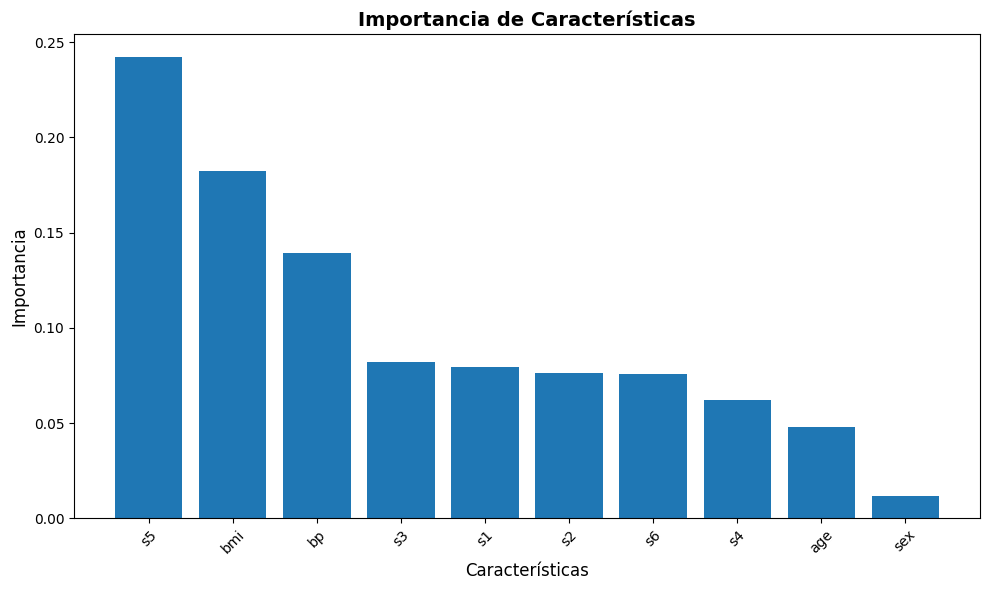

In [11]:
importancias = modelo.feature_importances_
indices = np.argsort(importancias)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Importancia de Características", fontsize=14, fontweight='bold')
plt.bar(range(X.shape[1]), importancias[indices], align="center")
plt.xticks(range(X.shape[1]), [diabetes.feature_names[i] for i in indices], rotation=45)
plt.xlabel("Características", fontsize=12)
plt.ylabel("Importancia", fontsize=12)
plt.tight_layout()
plt.show()